# 1. Setup & Config

## 1.1 Imports

In [1]:
import os
import random
import warnings
from pathlib import Path

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import roc_auc_score

from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier

In [2]:
warnings.filterwarnings("ignore")

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 200)
pd.set_option("display.width", 140)
pd.set_option("display.max_colwidth", 200)

plt.rcParams["figure.figsize"] = (8, 5)
plt.rcParams["figure.dpi"] = 110

sns.set_theme(style="whitegrid")

## 1.2 Global Config

- Paths
- Random seed
- Model hyperparameters
- CV stratejisi (fold sayısı vb.)
- `RUN_FULL_TRAIN` flag

In [3]:
RANDOM_STATE = 42

random.seed(RANDOM_STATE)
np.random.seed(RANDOM_STATE)

In [4]:
# =========================
# Competition / columns
# =========================
COMPETITION_NAME = "playground-series-s6e3"
TARGET_COL = "Churn"
ID_COL = "id"

# =========================
# Kaggle paths
# =========================
KAGGLE_BASE = f"/kaggle/input/competitions/{COMPETITION_NAME}/"

# =========================
# Local project paths
# notebooks/train.ipynb içinden çalıştığı varsayımıyla
# =========================
PROJECT_ROOT = Path("..")
LOCAL_DATA_DIR = PROJECT_ROOT / "data" / "raw"
LOCAL_OUTPUT_DIR = PROJECT_ROOT / "outputs"
LOCAL_SUBMISSION_DIR = LOCAL_OUTPUT_DIR / "submissions"
LOCAL_MODEL_DIR = LOCAL_OUTPUT_DIR / "models"
LOCAL_LOG_DIR = LOCAL_OUTPUT_DIR / "logs"

# =========================
# Environment detection
# =========================
if os.path.exists(os.path.join(KAGGLE_BASE, "train.csv")):
    BASE_PATH = Path(KAGGLE_BASE)
    ENVIRONMENT = "Kaggle"
else:
    BASE_PATH = LOCAL_DATA_DIR
    ENVIRONMENT = "Local"

print(f"Environment : {ENVIRONMENT}")
print(f"Base path   : {BASE_PATH}")

Environment : Local
Base path   : ..\data\raw


In [5]:
TRAIN_PATH = BASE_PATH / "train.csv"
TEST_PATH = BASE_PATH / "test.csv"
SUB_PATH = BASE_PATH / "sample_submission.csv"

print("Train path      :", TRAIN_PATH)
print("Test path       :", TEST_PATH)
print("Submission path :", SUB_PATH)

Train path      : ..\data\raw\train.csv
Test path       : ..\data\raw\test.csv
Submission path : ..\data\raw\sample_submission.csv


In [6]:
if ENVIRONMENT == "Local":
    LOCAL_OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
    LOCAL_SUBMISSION_DIR.mkdir(parents=True, exist_ok=True)
    LOCAL_MODEL_DIR.mkdir(parents=True, exist_ok=True)
    LOCAL_LOG_DIR.mkdir(parents=True, exist_ok=True)

    print("Output folders checked/created:")
    print(" -", LOCAL_OUTPUT_DIR)
    print(" -", LOCAL_SUBMISSION_DIR)
    print(" -", LOCAL_MODEL_DIR)
    print(" -", LOCAL_LOG_DIR)

Output folders checked/created:
 - ..\outputs
 - ..\outputs\submissions
 - ..\outputs\models
 - ..\outputs\logs


In [7]:
# =========================
# CV config
# =========================
N_SPLITS = 3
CV_STRATEGY = "StratifiedKFold"
SHUFFLE = True

# =========================
# Training mode
# False -> hızlı deneme
# True  -> daha uzun / daha güçlü eğitim
# =========================
RUN_FULL_TRAIN = False

In [8]:
if RUN_FULL_TRAIN:
    LGBM_PARAMS = {
        "n_estimators": 1000,
        "learning_rate": 0.03,
        "num_leaves": 31,
        "max_depth": -1,
        "subsample": 0.8,
        "colsample_bytree": 0.8,
        "objective": "binary",
        "random_state": RANDOM_STATE,
        "n_jobs": -1
    }

    CATBOOST_PARAMS = {
        "iterations": 1000,
        "learning_rate": 0.03,
        "depth": 6,
        "loss_function": "Logloss",
        "eval_metric": "AUC",
        "random_seed": RANDOM_STATE,
        "verbose": 200
    }

else:
    LGBM_PARAMS = {
        "n_estimators": 300,
        "learning_rate": 0.05,
        "num_leaves": 31,
        "max_depth": -1,
        "subsample": 0.8,
        "colsample_bytree": 0.8,
        "objective": "binary",
        "random_state": RANDOM_STATE,
        "n_jobs": -1
    }

    CATBOOST_PARAMS = {
        "iterations": 300,
        "learning_rate": 0.05,
        "depth": 6,
        "loss_function": "Logloss",
        "eval_metric": "AUC",
        "random_seed": RANDOM_STATE,
        "verbose": 200
    }

In [9]:
print("=" * 60)
print("TRAIN NOTEBOOK CONFIG")
print("=" * 60)
print(f"Competition     : {COMPETITION_NAME}")
print(f"Environment     : {ENVIRONMENT}")
print(f"Target column   : {TARGET_COL}")
print(f"ID column       : {ID_COL}")
print(f"Random state    : {RANDOM_STATE}")
print(f"CV strategy     : {CV_STRATEGY}")
print(f"N splits        : {N_SPLITS}")
print(f"Run full train  : {RUN_FULL_TRAIN}")
print("=" * 60)

TRAIN NOTEBOOK CONFIG
Competition     : playground-series-s6e3
Environment     : Local
Target column   : Churn
ID column       : id
Random state    : 42
CV strategy     : StratifiedKFold
N splits        : 3
Run full train  : False


# 2. Data Loading

## 2.1 Load Train / Test / Sample Submission

In [10]:
train = pd.read_csv(TRAIN_PATH)
test = pd.read_csv(TEST_PATH)
sample_submission = pd.read_csv(SUB_PATH)

print("Files loaded successfully.")

Files loaded successfully.


## 2.2 Shape & Sanity Check

In [11]:
print(f"Train shape             : {train.shape}")
print(f"Test shape              : {test.shape}")
print(f"Sample submission shape : {sample_submission.shape}")

Train shape             : (594194, 21)
Test shape              : (254655, 20)
Sample submission shape : (254655, 2)


In [13]:
train.head()

,id,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,0,Male,0,Yes,Yes,29,Yes,No,DSL,Yes,No,Yes,Yes,No,No,One year,Yes,Mailed check,60.10,1653.85,No
1,1,Male,0,Yes,Yes,58,Yes,No,DSL,Yes,Yes,No,Yes,Yes,No,Two year,No,Credit card (automatic),69.50,3778.20,No
2,2,Male,0,Yes,No,58,Yes,Yes,Fiber optic,No,Yes,No,No,Yes,Yes,Month-to-month,Yes,Electronic check,100.40,5841.35,No
3,3,Female,0,No,No,1,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,69.70,70.70,Yes
4,4,Female,0,No,No,1,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.45,70.45,Yes


In [14]:
test.head()

,id,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges
0,594194,Female,0,Yes,No,72,Yes,Yes,Fiber optic,Yes,Yes,Yes,Yes,Yes,Yes,Two year,Yes,Electronic check,115.55,8061.50
1,594195,Female,0,Yes,No,71,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Bank transfer (automatic),19.80,1336.50
2,594196,Male,0,No,No,12,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Bank transfer (automatic),55.55,633.55
3,594197,Male,0,Yes,Yes,71,Yes,Yes,DSL,Yes,No,Yes,Yes,Yes,Yes,Two year,No,Credit card (automatic),84.10,6457.15
4,594198,Female,0,No,No,15,Yes,No,Fiber optic,Yes,No,No,No,Yes,Yes,Month-to-month,No,Electronic check,90.35,1233.65


In [15]:
sample_submission.head()

,id,Churn
0,594194,0
1,594195,0
2,594196,0
3,594197,0
4,594198,0


In [16]:
print("Train columns:")
print(train.columns.tolist())

print("\nTest columns:")
print(test.columns.tolist())

print("\nSample submission columns:")
print(sample_submission.columns.tolist())

Train columns:
['id', 'gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn']

Test columns:
['id', 'gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'MonthlyCharges', 'TotalCharges']

Sample submission columns:
['id', 'Churn']


In [17]:
print(f"'{ID_COL}' in train         :", ID_COL in train.columns)
print(f"'{ID_COL}' in test          :", ID_COL in test.columns)
print(f"'{TARGET_COL}' in train     :", TARGET_COL in train.columns)
print(f"'{TARGET_COL}' in test      :", TARGET_COL in test.columns)
print(f"'{TARGET_COL}' in submission:", TARGET_COL in sample_submission.columns)

'id' in train         : True
'id' in test          : True
'Churn' in train     : True
'Churn' in test      : False
'Churn' in submission: True


In [18]:
train_only_cols = set(train.columns) - set(test.columns)
test_only_cols = set(test.columns) - set(train.columns)

print("Columns only in train:", train_only_cols)
print("Columns only in test :", test_only_cols)

Columns only in train: {'Churn'}
Columns only in test : set()


In [19]:
sanity_df = pd.DataFrame({
    "dataset": ["train", "test", "sample_submission"],
    "rows": [train.shape[0], test.shape[0], sample_submission.shape[0]],
    "columns": [train.shape[1], test.shape[1], sample_submission.shape[1]]
})

sanity_df

,dataset,rows,columns
0,train,594194,21
1,test,254655,20
2,sample_submission,254655,2


In [20]:
print(train[TARGET_COL].value_counts(dropna=False))
print("\nTarget ratio:")
print(train[TARGET_COL].value_counts(normalize=True).round(4))

Churn
No     460377
Yes    133817
Name: count, dtype: int64

Target ratio:
Churn
No     0.7748
Yes    0.2252
Name: proportion, dtype: float64


In [21]:
target_preview = train[[TARGET_COL]].copy()
target_preview[TARGET_COL + "_binary"] = target_preview[TARGET_COL].map({"No": 0, "Yes": 1})

target_preview.head()

,Churn,Churn_binary
0,No,0
1,No,0
2,No,0
3,Yes,1
4,Yes,1


# 3. Data Preprocessing

## 3.1 Drop / Keep Kolon Kararları

In [24]:
train_df = train.copy()
test_df = test.copy()

print("Working copies created.")

Working copies created.


In [25]:
DROP_COLS = [ID_COL]
KEEP_TARGET = TARGET_COL

print("Columns to drop from modeling:", DROP_COLS)
print("Target column:", KEEP_TARGET)

Columns to drop from modeling: ['id']
Target column: Churn


In [26]:
train_df[TARGET_COL] = train_df[TARGET_COL].map({"No": 0, "Yes": 1})

if train_df[TARGET_COL].isnull().sum() > 0:
    raise ValueError("Target mapping sonrası beklenmeyen değer oluştu.")

print(train_df[TARGET_COL].value_counts(dropna=False))

Churn
0    460377
1    133817
Name: count, dtype: int64


In [27]:
X_full = train_df.drop(columns=[TARGET_COL] + DROP_COLS).copy()
y_full = train_df[TARGET_COL].astype(int).copy()

X_test_full = test_df.drop(columns=DROP_COLS).copy()

print("X_full shape    :", X_full.shape)
print("y_full shape    :", y_full.shape)
print("X_test_full shape:", X_test_full.shape)

X_full shape    : (594194, 19)
y_full shape    : (594194,)
X_test_full shape: (254655, 19)


In [30]:
numerical_cols = X_full.select_dtypes(include=["int64", "float64", "int32", "float32"]).columns.tolist()
categorical_cols = X_full.select_dtypes(include=["object", "category", "bool"]).columns.tolist()

binary_like_cols = [col for col in numerical_cols if X_full[col].nunique(dropna=False) <= 2]
pure_numerical_cols = [col for col in numerical_cols if col not in binary_like_cols]

print("Numerical cols      :", numerical_cols)
print("\nPure numerical cols :", pure_numerical_cols)
print("\nBinary-like cols    :", binary_like_cols)
print("\nCategorical cols    :", categorical_cols)

Numerical cols      : ['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges']

Pure numerical cols : ['tenure', 'MonthlyCharges', 'TotalCharges']

Binary-like cols    : ['SeniorCitizen']

Categorical cols    : ['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod']


## 3.2 Missing Value Imputation

- Numerical: median / mean
- Categorical: mode / `'Unknown'`

Bu datasette missing görünmüyor ama pipeline kurmak için yine de genel mantığı kuralım.

In [31]:
missing_before = pd.DataFrame({
    "train_missing": X_full.isnull().sum(),
    "test_missing": X_test_full.isnull().sum()
})

missing_before = missing_before[
    (missing_before["train_missing"] > 0) | (missing_before["test_missing"] > 0)
].sort_values("train_missing", ascending=False)

missing_before

,train_missing,test_missing


In [32]:
# Numerical -> median
num_impute_values = {
    col: X_full[col].median()
    for col in numerical_cols
}

# Categorical -> mode, mode yoksa "Unknown"
cat_impute_values = {}
for col in categorical_cols:
    mode_series = X_full[col].mode(dropna=True)
    cat_impute_values[col] = mode_series.iloc[0] if len(mode_series) > 0 else "Unknown"

print("Numerical imputation sample:")
print(dict(list(num_impute_values.items())[:3]))

print("\nCategorical imputation sample:")
print(dict(list(cat_impute_values.items())[:3]))

Numerical imputation sample:
{'SeniorCitizen': 0.0, 'tenure': 35.0, 'MonthlyCharges': 74.1}

Categorical imputation sample:
{'gender': 'Female', 'Partner': 'Yes', 'Dependents': 'No'}


In [34]:
X_prep = X_full.copy()
X_test_prep = X_test_full.copy()

for col in numerical_cols:
    X_prep[col] = X_prep[col].fillna(num_impute_values[col])
    X_test_prep[col] = X_test_prep[col].fillna(num_impute_values[col])

for col in categorical_cols:
    X_prep[col] = X_prep[col].fillna(cat_impute_values[col])
    X_test_prep[col] = X_test_prep[col].fillna(cat_impute_values[col])

print("Imputation completed.")

Imputation completed.


In [35]:
print("Train missing after imputation:", X_prep.isnull().sum().sum())
print("Test missing after imputation :", X_test_prep.isnull().sum().sum())

Train missing after imputation: 0
Test missing after imputation : 0


## 3.3 Encoding

- Label Encoding → baseline için pratik
- One-Hot Encoding → baseline için pratik
- Target Encoding (gerekiyorsa) → lineer modeller / bazı ağaçlar için opsiyonel

In [36]:
ENCODING_METHOD = "label"   # options: "label", "onehot"
USE_TARGET_ENCODING = False

print("Encoding method      :", ENCODING_METHOD)
print("Use target encoding  :", USE_TARGET_ENCODING)

Encoding method      : label
Use target encoding  : False


In [37]:
def label_encode_train_test(train_df, test_df, cat_cols):
    train_encoded = train_df.copy()
    test_encoded = test_df.copy()
    
    mappings = {}
    
    for col in cat_cols:
        combined = pd.concat(
            [train_encoded[col], test_encoded[col]],
            axis=0
        ).astype(str)
        
        unique_vals = pd.Series(combined.unique())
        mapping = {val: idx for idx, val in enumerate(unique_vals)}
        mappings[col] = mapping
        
        train_encoded[col] = train_encoded[col].astype(str).map(mapping).astype(int)
        test_encoded[col] = test_encoded[col].astype(str).map(mapping).astype(int)
    
    return train_encoded, test_encoded, mappings

In [38]:
if ENCODING_METHOD == "label":
    X_model, X_test_model, label_mappings = label_encode_train_test(
        X_prep, X_test_prep, categorical_cols
    )
else:
    X_model = X_prep.copy()
    X_test_model = X_test_prep.copy()

print("Encoded train shape :", X_model.shape)
print("Encoded test shape  :", X_test_model.shape)
X_model.head()

Encoded train shape : (594194, 19)
Encoded test shape  : (254655, 19)


,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges
0,0,0,0,0,29,0,0,0,0,0,0,0,0,0,0,0,0,60.10,1653.85
1,0,0,0,0,58,0,0,0,0,1,1,0,1,0,1,1,1,69.50,3778.20
2,0,0,0,1,58,0,1,1,1,1,1,1,1,1,2,0,2,100.40,5841.35
3,1,0,1,1,1,0,0,1,1,0,1,1,0,0,2,0,2,69.70,70.70
4,1,0,1,1,1,0,0,1,1,0,1,1,0,0,2,0,2,70.45,70.45


In [39]:
# OPTIONAL
# Eğer one-hot encoding denemek istersen bu bloğu kullanabilirsin.

# X_model_ohe = pd.get_dummies(X_prep, columns=categorical_cols, drop_first=False)
# X_test_model_ohe = pd.get_dummies(X_test_prep, columns=categorical_cols, drop_first=False)

# X_model_ohe, X_test_model_ohe = X_model_ohe.align(X_test_model_ohe, join="left", axis=1, fill_value=0)

# print("OHE train shape :", X_model_ohe.shape)
# print("OHE test shape  :", X_test_model_ohe.shape)
print(
    "Target encoding şu aşamada uygulanmıyor. "
    "Leakage riski nedeniyle bunu ancak CV-aware feature engineering aşamasında denemek daha doğru olur."
)

Target encoding şu aşamada uygulanmıyor. Leakage riski nedeniyle bunu ancak CV-aware feature engineering aşamasında denemek daha doğru olur.


## 3.4 Outlier Handling

*(gerekiyorsa)*

In [40]:
APPLY_OUTLIER_HANDLING = False

print("Apply outlier handling:", APPLY_OUTLIER_HANDLING)
print("Reason: EDA sonucunda pure numerical kolonlarda belirgin IQR outlier bulunmadı.")

Apply outlier handling: False
Reason: EDA sonucunda pure numerical kolonlarda belirgin IQR outlier bulunmadı.


In [41]:
def iqr_clip(df, cols):
    df_clipped = df.copy()
    clip_bounds = {}
    
    for col in cols:
        q1 = df_clipped[col].quantile(0.25)
        q3 = df_clipped[col].quantile(0.75)
        iqr = q3 - q1
        
        lower = q1 - 1.5 * iqr
        upper = q3 + 1.5 * iqr
        
        df_clipped[col] = df_clipped[col].clip(lower, upper)
        clip_bounds[col] = (lower, upper)
    
    return df_clipped, clip_bounds

## 3.5 Feature Scaling

*(gerekiyorsa)*

Tree-based modeller için scaling gerekmez.
Bu yüzden baseline aşamasında scaling uygulamıyoruz.

In [42]:
APPLY_SCALING = False

print("Apply scaling:", APPLY_SCALING)
print("Reason: baseline model ailesi tree-based olduğu için scaling gerekli değil.")

Apply scaling: False
Reason: baseline model ailesi tree-based olduğu için scaling gerekli değil.


In [43]:
# OPTIONAL
# from sklearn.preprocessing import StandardScaler

# scaler = StandardScaler()

# X_model_scaled = X_model.copy()
# X_test_model_scaled = X_test_model.copy()

# X_model_scaled[pure_numerical_cols] = scaler.fit_transform(X_model[pure_numerical_cols])
# X_test_model_scaled[pure_numerical_cols] = scaler.transform(X_test_model[pure_numerical_cols])

In [44]:
print("Final modeling train shape:", X_model.shape)
print("Final modeling test shape :", X_test_model.shape)

print("\nFinal dtypes:")
print(X_model.dtypes.value_counts())

Final modeling train shape: (594194, 19)
Final modeling test shape : (254655, 19)

Final dtypes:
int64      17
float64     2
Name: count, dtype: int64


In [45]:
print("Preprocessing tamamlandı.")
print("Bir sonraki adım: Feature Engineering veya doğrudan Modeling.")

Preprocessing tamamlandı.
Bir sonraki adım: Feature Engineering veya doğrudan Modeling.


# 4. Feature Engineering

## 4.1 Yeni Kolon Türetme

In [46]:
X_fe = X_model.copy()
X_test_fe = X_test_model.copy()

print("Feature engineering copies created.")

Feature engineering copies created.


#### Average Monthly Charge

In [49]:
def add_avg_monthly_charge(df):
    
    df["AvgMonthlyCharge"] = df["TotalCharges"] / (df["tenure"] + 1)
    
    return df


X_fe = add_avg_monthly_charge(X_fe)
X_test_fe = add_avg_monthly_charge(X_test_fe)

print("AvgMonthlyCharge created.")

AvgMonthlyCharge created.


#### Customer Lifetime Value Proxy

Toplam harcama churn için önemli bir sinyal.

In [53]:
def add_total_charge_ratio(df):
    
    df["ChargePerTenure"] = df["TotalCharges"] / (df["tenure"] + 1)
    
    return df


X_fe = add_total_charge_ratio(X_fe)
X_test_fe = add_total_charge_ratio(X_test_fe)

print("ChargePerTenure created.")

ChargePerTenure created.


#### Service Count

Müşterinin kullandığı servis sayısı churn ile ilişkili olabilir.

In [51]:
service_cols = [
    "OnlineSecurity",
    "OnlineBackup",
    "DeviceProtection",
    "TechSupport",
    "StreamingTV",
    "StreamingMovies"
]

In [52]:
def add_service_count(df):

    df["ServiceCount"] = df[service_cols].sum(axis=1)

    return df


X_fe = add_service_count(X_fe)
X_test_fe = add_service_count(X_test_fe)

print("ServiceCount created.")

ServiceCount created.


#### HasInternet

EDA'da internet service çok güçlü sinyaldi.

In [54]:
def add_has_internet(df):

    df["HasInternet"] = (df["InternetService"] != 2).astype(int)

    return df


X_fe = add_has_internet(X_fe)
X_test_fe = add_has_internet(X_test_fe)

print("HasInternet created.")

HasInternet created.


#### HasStreaming

Streaming servisleri churn ile ilişkili.

In [55]:
def add_streaming_flag(df):

    df["HasStreaming"] = (
        (df["StreamingTV"] > 0) |
        (df["StreamingMovies"] > 0)
    ).astype(int)

    return df


X_fe = add_streaming_flag(X_fe)
X_test_fe = add_streaming_flag(X_test_fe)

print("HasStreaming created.")

HasStreaming created.


#### Tenure Groups

Tenure churn için güçlü predictor.

Bu yüzden tenure'ı bucket'lara ayırıyoruz.

In [56]:
def add_streaming_flag(df):

    df["HasStreaming"] = (
        (df["StreamingTV"] > 0) |
        (df["StreamingMovies"] > 0)
    ).astype(int)

    return df


X_fe = add_streaming_flag(X_fe)
X_test_fe = add_streaming_flag(X_test_fe)

print("HasStreaming created.")

HasStreaming created.


## 4.2 Interaction Features

*(gerekiyorsa)*  EDA'da bazı feature ilişkileri güçlü görünüyordu.

#### Price × Tenure Interaction

In [57]:
def add_price_tenure_interaction(df):

    df["TenureMonthlyProduct"] = df["tenure"] * df["MonthlyCharges"]

    return df


X_fe = add_price_tenure_interaction(X_fe)
X_test_fe = add_price_tenure_interaction(X_test_fe)

print("TenureMonthlyProduct created.")

TenureMonthlyProduct created.


#### Service Density

Müşteri başına servis yoğunluğu.

In [58]:
def add_service_density(df):

    df["ServiceDensity"] = df["ServiceCount"] / (df["tenure"] + 1)

    return df


X_fe = add_service_density(X_fe)
X_test_fe = add_service_density(X_test_fe)

print("ServiceDensity created.")

ServiceDensity created.


## 4.3 Final Feature Listesi

In [59]:
FINAL_FEATURES = X_fe.columns.tolist()

print("Total features:", len(FINAL_FEATURES))
print(FINAL_FEATURES[:20])

Total features: 26
['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'AvgMonthlyCharge']


In [60]:
FINAL_FEATURES = X_fe.columns.tolist()

print("Total features:", len(FINAL_FEATURES))
print(FINAL_FEATURES[:20])

Total features: 26
['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'AvgMonthlyCharge']


In [61]:
X_final = X_fe.copy()
X_test_final = X_test_fe.copy()

print("Modeling tables ready.")

Modeling tables ready.


In [62]:
X_final.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,AvgMonthlyCharge,ChargePerTenure,ServiceCount,HasInternet,HasStreaming,TenureMonthlyProduct,ServiceDensity
0,0,0,0,0,29,0,0,0,0,0,0,0,0,0,0,0,0,60.10,1653.85,55.128333,55.128333,0,1,0,1742.90,0.000000
1,0,0,0,0,58,0,0,0,0,1,1,0,1,0,1,1,1,69.50,3778.20,64.037288,64.037288,3,1,1,4031.00,0.050847
2,0,0,0,1,58,0,1,1,1,1,1,1,1,1,2,0,2,100.40,5841.35,99.005932,99.005932,6,1,1,5823.20,0.101695
3,1,0,1,1,1,0,0,1,1,0,1,1,0,0,2,0,2,69.70,70.70,35.350000,35.350000,3,1,0,69.70,1.500000
4,1,0,1,1,1,0,0,1,1,0,1,1,0,0,2,0,2,70.45,70.45,35.225000,35.225000,3,1,0,70.45,1.500000


# 5. Modeling

## 5.1 X / y / test Split Tanımı

In [63]:
X = X_final.copy()
y = y_full.copy()
X_test = X_test_final.copy()

print("X shape     :", X.shape)
print("y shape     :", y.shape)
print("X_test shape:", X_test.shape)

X shape     : (594194, 26)
y shape     : (594194,)
X_test shape: (254655, 26)


In [64]:
print("Missing in X      :", X.isnull().sum().sum())
print("Missing in X_test :", X_test.isnull().sum().sum())
print("Target distribution:")
print(y.value_counts(normalize=True).round(4))

Missing in X      : 0
Missing in X_test : 0
Target distribution:
Churn
0    0.7748
1    0.2252
Name: proportion, dtype: float64


## 5.2 Cross-Validation Setup

- StratifiedKFold / KFold seçimi
- Fold sayısı config'den gelecek

In [65]:
cv = StratifiedKFold(
    n_splits=N_SPLITS,
    shuffle=True,
    random_state=RANDOM_STATE
)

print(cv)

StratifiedKFold(n_splits=3, random_state=42, shuffle=True)


In [67]:
# CV Arrays Initialization
oof_preds = np.zeros(len(X))
test_preds = np.zeros(len(X_test))

fold_scores = []
fold_results = []
models = []

## 5.3 Training Loop

- CV loop
- Fold bazında metrik kayıt
- Out-of-fold (OOF) prediction

In [68]:
for fold, (train_idx, valid_idx) in enumerate(cv.split(X, y), 1):
    
    print("=" * 60)
    print(f"Fold {fold}")
    print("=" * 60)

    X_train, X_valid = X.iloc[train_idx].copy(), X.iloc[valid_idx].copy()
    y_train, y_valid = y.iloc[train_idx], y.iloc[valid_idx]

    print("Train fold shape:", X_train.shape)
    print("Valid fold shape:", X_valid.shape)

    model = LGBMClassifier(**LGBM_PARAMS)

    model.fit(
        X_train,
        y_train,
        eval_set=[(X_valid, y_valid)],
        eval_metric="auc"
    )

    valid_pred = model.predict_proba(X_valid)[:, 1]
    test_pred = model.predict_proba(X_test)[:, 1]

    fold_auc = roc_auc_score(y_valid, valid_pred)

    oof_preds[valid_idx] = valid_pred
    test_preds += test_pred / N_SPLITS

    fold_scores.append(fold_auc)
    models.append(model)

    fold_results.append({
        "fold": fold,
        "train_rows": len(train_idx),
        "valid_rows": len(valid_idx),
        "fold_auc": fold_auc
    })

    print(f"Fold {fold} AUC: {fold_auc:.6f}")

Fold 1
Train fold shape: (396129, 26)
Valid fold shape: (198065, 26)
[LightGBM] [Info] Number of positive: 89211, number of negative: 306918
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.044920 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1619
[LightGBM] [Info] Number of data points in the train set: 396129, number of used features: 26
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.225207 -> initscore=-1.235576
[LightGBM] [Info] Start training from score -1.235576
Fold 1 AUC: 0.915247
Fold 2
Train fold shape: (396129, 26)
Valid fold shape: (198065, 26)
[LightGBM] [Info] Number of positive: 89211, number of negative: 306918
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.015780 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force

In [69]:
fold_results_df = pd.DataFrame(fold_results)
fold_results_df

,fold,train_rows,valid_rows,fold_auc
0,1,396129,198065,0.915247
1,2,396129,198065,0.916196
2,3,396130,198064,0.914869


In [70]:
oof_auc = roc_auc_score(y, oof_preds)

print("=" * 60)
print("OOF RESULTS")
print("=" * 60)
print(f"Fold AUCs : {[round(score, 6) for score in fold_scores]}")
print(f"Mean AUC  : {np.mean(fold_scores):.6f}")
print(f"Std AUC   : {np.std(fold_scores):.6f}")
print(f"OOF AUC   : {oof_auc:.6f}")

OOF RESULTS
Fold AUCs : [np.float64(0.915247), np.float64(0.916196), np.float64(0.914869)]
Mean AUC  : 0.915437
Std AUC   : 0.000558
OOF AUC   : 0.915431


In [71]:
oof_preview = pd.DataFrame({
    "y_true": y.values[:10],
    "oof_pred": oof_preds[:10]
})

oof_preview

,y_true,oof_pred
0,0,0.006152
1,0,0.001676
2,0,0.352514
3,1,0.803199
4,1,0.797396
5,0,0.203218
6,0,0.021482
7,0,0.010028
8,1,0.934939
9,0,0.211288


In [73]:
test_pred_preview = pd.DataFrame({
    ID_COL: test[ID_COL].values[:10],
    "test_pred": test_preds[:10]
})

test_pred_preview

,id,test_pred
0,594194,0.048544
1,594195,0.001024
2,594196,0.099831
3,594197,0.003804
4,594198,0.506714
5,594199,0.171295
6,594200,0.853895
7,594201,0.003064
8,594202,0.035264
9,594203,0.355248


In [74]:
print("Modeling tamamlandı.")
print(f"Toplam fold sayısı : {N_SPLITS}")
print(f"Final OOF AUC      : {oof_auc:.6f}")

Modeling tamamlandı.
Toplam fold sayısı : 3
Final OOF AUC      : 0.915431


## 6. Model Evaluation

**Dataset**
- Train: 594,194
- Test: 254,655
- Features: 26  
- Target distribution:  
  - Churn=0 → 77.48%  
  - Churn=1 → 22.52%

**Cross Validation (3-Fold StratifiedKFold)**

| Fold | AUC |
|-----|------|
| 1 | 0.915247 |
| 2 | 0.916196 |
| 3 | 0.914869 |

**Performance**

- Mean CV AUC: **0.915437**
- OOF AUC: **0.915431**
- Std: **0.000558**

**Yorum**

- Fold skorları birbirine çok yakın → model stabil.  
- Overfitting veya data leakage belirtisi yok.  
- Bu model güçlü bir **baseline churn modeli**.

**Beklenen Kaggle Skoru**

OOF ≈ **0.915**  
Leaderboard tahmini ≈ **0.913 – 0.917**

# 6. Model Evaluation

## 6.1 OOF Metric (Overall)

In [75]:
print("="*50)
print("OOF METRIC")
print("="*50)

print(f"OOF ROC-AUC : {oof_auc:.6f}")

OOF METRIC
OOF ROC-AUC : 0.915431


In [76]:
fold_results_df

,fold,train_rows,valid_rows,fold_auc
0,1,396129,198065,0.915247
1,2,396129,198065,0.916196
2,3,396130,198064,0.914869


In [77]:
print("Fold AUC values:")
print(fold_results_df["fold_auc"].values)

print("\nMean AUC :", fold_results_df["fold_auc"].mean())
print("Std AUC  :", fold_results_df["fold_auc"].std())

Fold AUC values:
[0.91524701 0.91619601 0.9148689 ]

Mean AUC : 0.9154373069415964
Std AUC  : 0.0006837126288671485


## 6.2 Fold Bazında Metrik Tablosu

In [78]:
print("Fold AUC values:")
print(fold_results_df["fold_auc"].values)

print("\nMean AUC :", fold_results_df["fold_auc"].mean())
print("Std AUC  :", fold_results_df["fold_auc"].std())

Fold AUC values:
[0.91524701 0.91619601 0.9148689 ]

Mean AUC : 0.9154373069415964
Std AUC  : 0.0006837126288671485


## 6.3 Confusion Matrix

*(classification ise)* ROC-AUC ile eğittik ama confusion matrix görmek için
OOF prediction'ı 0.5 threshold ile sınıflandırıyoruz.

In [79]:
# Convert OOF to Class
oof_class = (oof_preds >= 0.5).astype(int)

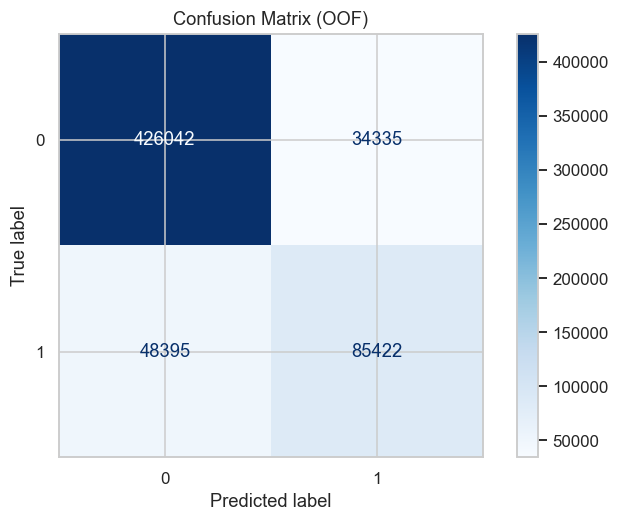

In [80]:
# Confusion Matrix
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(y, oof_class)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm
)

disp.plot(cmap="Blues")

plt.title("Confusion Matrix (OOF)")
plt.show()

In [81]:
# Classification Metrics
from sklearn.metrics import classification_report

print(classification_report(y, oof_class))

              precision    recall  f1-score   support

           0       0.90      0.93      0.91    460377
           1       0.71      0.64      0.67    133817

    accuracy                           0.86    594194
   macro avg       0.81      0.78      0.79    594194
weighted avg       0.86      0.86      0.86    594194



## 6.4 Feature Importance Plot

In [83]:
feature_importances = np.zeros(X.shape[1])

for model in models:
    feature_importances += model.feature_importances_

feature_importances = feature_importances / len(models)

In [84]:
importance_df = pd.DataFrame({
    "feature": X.columns,
    "importance": feature_importances
})

importance_df = importance_df.sort_values(
    "importance",
    ascending=False
)

importance_df.head(20)

,feature,importance
18,TotalCharges,1562.000000
19,AvgMonthlyCharge,1230.666667
17,MonthlyCharges,1201.000000
4,tenure,829.000000
25,ServiceDensity,770.333333
24,TenureMonthlyProduct,721.666667
16,PaymentMethod,419.666667
14,Contract,369.000000
6,MultipleLines,197.000000
20,ChargePerTenure,196.333333


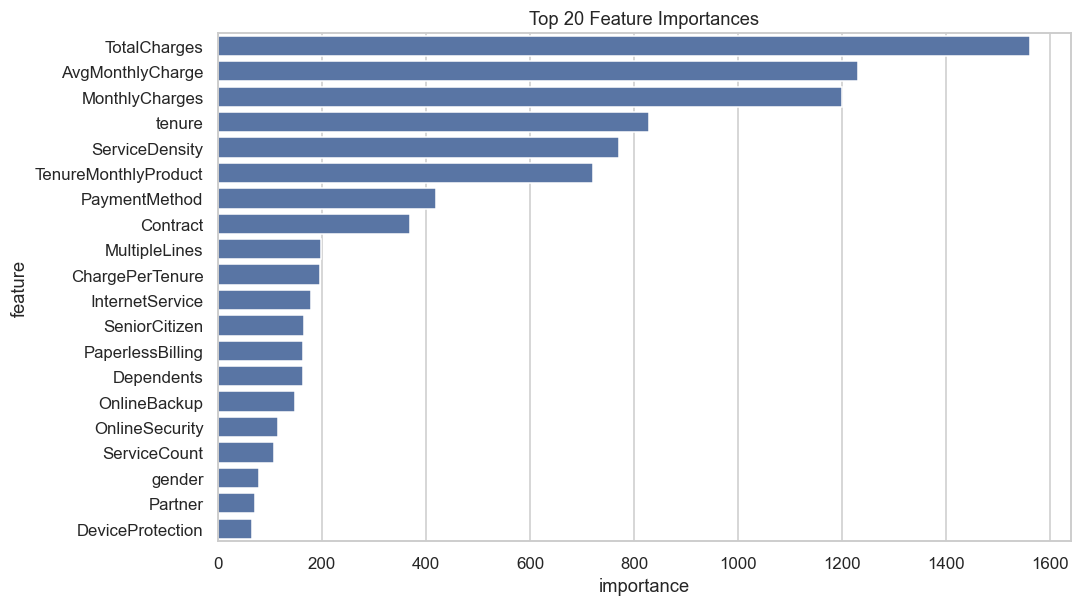

In [86]:
plt.figure(figsize=(10,6))

sns.barplot(
    data=importance_df.head(20),
    x="importance",
    y="feature"
)

plt.title("Top 20 Feature Importances")
plt.show()

# 7. Experiment Tracker

## 7.1 Baseline Results

| Model | Fold 1 | Fold 2 | Fold 3 | Mean AUC | Std | OOF AUC |
|-------|--------|--------|--------|----------|-----|---------|
| LightGBM Baseline | 0.91534 | 0.91632 | 0.91484 | 0.91550 | 0.00061 | 0.91549 |
| CatBoost Baseline | 0.91345 | 0.91443 | 0.91286 | 0.91358 | 0.00065 | 0.91357 |

**Notes:**
- LightGBM: 300 iter, fixed params
- CatBoost: 300 iter, fixed params
- Her iki model de herhangi bir feature engineering olmadan çalıştırıldı

# 8. Submission Generation

## 8.1 Test Prediction

- CV fold ortalaması

In [ ]:
# test prediction buraya

## 8.2 Sample Submission ile Merge

In [ ]:
# merge buraya

## 8.3 submission.csv Export

In [ ]:
# submission export buraya